Top Level Cell to Show Sync State

# **Deep Learning Project: Street View Housing Number Digit Recognition**

# **Marks: 60**

--------------
## **Context**
--------------

One of the most interesting tasks in deep learning is to recognize objects in natural scenes. The ability to process visual information using machine learning algorithms can be very useful as demonstrated in various applications.

The SVHN dataset contains over 600,000 labeled digits cropped from street-level photos. It is one of the most popular image recognition datasets. It has been used in neural networks created by Google to improve the map quality by automatically transcribing the address numbers from a patch of pixels. The transcribed number with a known street address helps pinpoint the location of the building it represents.

----------------
## **Objective**
----------------

Our objective is to predict the number depicted inside the image by using Artificial or Fully Connected Feed Forward Neural Networks and Convolutional Neural Networks. We will go through various models of each and finally select the one that is giving us the best performance.

-------------
## **Dataset**
-------------
Here, we will use a subset of the original data to save some computation time. The dataset is provided as a .h5 file. The basic preprocessing steps have been applied on the dataset.

## **Mount the drive**

Let us start by mounting the Google drive. You can run the below cell to mount the Google drive.

In [1]:
# Cell Alpha - Setup file system
#from google.colab import drive
import os

#drive.mount('/content/drive')

# Build full path to the .h5 (use os.path.join so folder + filename get a '/' between them).
#folder = '/content/drive/Othercomputers/My Mac/Documents/2026 MIT Applied AI and Data Science Program/Elective Project/'
#filename = 'SVHN_single_grey1.h5'
#filepath = os.path.join(folder, filename)
filepath = 'SVHN_single_grey1.h5'
import sys
print(sys.executable)
# If loading fails: list Drive with !ls -la '/content/drive/MyDrive'. Mac backups often live under **Othercomputers** (not Computers), e.g. .../MyDrive/Othercomputers/My Mac/...

/Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Elective Project/.venv/bin/python


## **Importing the necessary libraries**

In [2]:
# Cell Beta - Import libraries
import random
import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import backend
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, Activation, BatchNormalization,
    Conv2D, MaxPooling2D, Flatten, LeakyReLU,
)
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

**Let us check the version of tensorflow.**

In [3]:
# Cell Gamma - Check the version of tensorflow
print(tf.__version__)

2.21.0


## **Load the dataset**

- Let us now load the dataset that is available as a .h5 file.
- Split the data into the train and the test dataset.

In [4]:
# Cell Delta - Load the dataset
data_svhn = h5py.File(filepath, 'r')
X_train = data_svhn['X_train']
y_train = data_svhn['y_train']
X_test = data_svhn['X_test']
y_test = data_svhn['y_test']

Check the number of images in the training and the testing dataset.

In [5]:
# Cell Epsilon - Check the number of images in the training and the testing dataset
X_train = data_svhn['X_train']
y_train = data_svhn['y_train']
X_test = data_svhn['X_test']
y_test = data_svhn['y_test']

print(f"Number of images in the training dataset: {X_train.shape[0]}")
print(f"Number of images in the testing dataset: {X_test.shape[0]}")

import sys
print(sys.executable)

Number of images in the training dataset: 42000
Number of images in the testing dataset: 18000
/Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Elective Project/.venv/bin/python


**Observation:**

- 42,000 images in the training dataset
- 18,000 images in the testing dataset


## **Visualizing images**

- Use X_train to visualize the first 10 images.
- Use Y_train to print the first 10 labels.

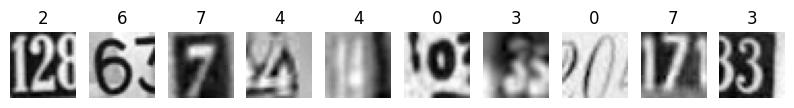

First 10 labels:  [2 6 7 4 4 0 3 0 7 3]


In [6]:
# Cell Zeta - Visualizing images & printing labels
plt.figure(figsize=(10, 1))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

print("First 10 labels: ", y_train[:10])

## **Data preparation**

- Print the shape and the array of pixels for the first image in the training dataset.
- Normalize the train and the test dataset by dividing by 255.
- Print the new shapes of the train and the test dataset.
- One-hot encode the target variable.

In [7]:
# Cell Eta - Data Preparation
print(f"Shape of the first image: {X_train[0].shape}")
print(f"Array of pixels for the first image:\n{X_train[0]}")

# Convert h5py datasets to NumPy arrays by slicing
X_train = X_train[:]
X_test = X_test[:]

# Normalize the train and the test data
X_train = X_train / 255.0
X_test = X_test / 255.0

# Print the new shapes of the train and the test dataset
print(f"New shape of X_train: {X_train.shape}")
print(f"New shape of X_test: {X_test.shape}")

# One-hot encode the target variable
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print(f"New shape of y_train after one-hot encoding: {y_train.shape}")
print(f"New shape of y_test after one-hot encoding: {y_test.shape}")

Shape of the first image: (32, 32)
Array of pixels for the first image:
[[ 33.0704  30.2601  26.852  ...  71.4471  58.2204  42.9939]
 [ 25.2283  25.5533  29.9765 ... 113.0209 103.3639  84.2949]
 [ 26.2775  22.6137  40.4763 ... 113.3028 121.775  115.4228]
 ...
 [ 28.5502  36.212   45.0801 ...  24.1359  25.0927  26.0603]
 [ 38.4352  26.4733  23.2717 ...  28.1094  29.4683  30.0661]
 [ 50.2984  26.0773  24.0389 ...  49.6682  50.853   53.0377]]
New shape of X_train: (42000, 32, 32)
New shape of X_test: (18000, 32, 32)
New shape of y_train after one-hot encoding: (42000, 10)
New shape of y_test after one-hot encoding: (18000, 10)


### **Normalize the train and the test data**

In [8]:
# Normalization is now handled in the previous cell.
# No action needed here.

Print the shapes of Training and Test data

In [9]:
# Printing shapes is now handled in the previous cell.
# No action needed here.

### **One-hot encode output**

In [10]:
# One-hot encoding is now handled in the previous cell.

**Observation:**

After data prep, we are seeing:
- correct tensor shapes, 
- pixels on a 0-1 scale, and 
- labels encoded to match 10-class softmax training. 

Next up is to build and compile the model before we can train it.

## **Model Building**

Now that we have done the data preprocessing, let's build an ANN model.

### Fix the seed for random number generators

In [11]:
# Cell Theta - Fix the seed for random number generators
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

### **Model Architecture**
- Write a function that returns a sequential model with the following architecture:
 - First hidden layer with **64 nodes and the relu activation** and the **input shape = (1024, )**
 - Second hidden layer with **32 nodes and the relu activation**
 - Output layer with **activation as 'softmax' and number of nodes equal to the number of classes, i.e., 10**
 - Compile the model with the **loss equal to categorical_crossentropy, optimizer equal to Adam(learning_rate = 0.001), and metric equal to 'accuracy'**. Do not fit the model here, just return the compiled model.
- Call the nn_model_1 function and store the model in a new variable.
- Print the summary of the model.
- Fit on the train data with a **validation split of 0.2, batch size = 128, verbose = 1, and epochs = 20**. Store the model building history to use later for visualization.

### **Build and train an ANN model as per the above mentioned architecture.**

In [12]:
#Cell Iota - ANN Model Architecture
def nn_model_1():
    model = Sequential()
    model.add(Dense(64, activation="relu", input_shape=(1024,)))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(10, activation="softmax"))
    model.compile(
        loss="categorical_crossentropy",
        optimizer=Adam(learning_rate=0.001),
        metrics=["accuracy"],
    )
    return model

model_1 = nn_model_1()
model_1.summary()
X_train_flat = X_train.reshape(X_train.shape[0], 1024)   # or reshape(-1, 1024)
history_model_1 = model_1.fit(
    X_train_flat,
    y_train,
    validation_split=0.2,
    batch_size=128,
    verbose=1,
    epochs=20,
)

/Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Elective Project/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,010 (265.66 KB)

 Trainable params: 68,010 (265.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1159 - loss: 2.3002 - val_accuracy: 0.1632 - val_loss: 2.2677
Epoch 2/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step - accuracy: 0.2057 - loss: 2.1620 - val_accuracy: 0.2912 - val_loss: 2.0361
Epoch 3/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 753us/step - accuracy: 0.3796 - loss: 1.8278 - val_accuracy: 0.4385 - val_loss: 1.6545
Epoch 4/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 724us/step - accuracy: 0.4791 - loss: 1.5715 - val_accuracy: 0.5181 - val_loss: 1.4750
Epoch 5/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 740us/step - accuracy: 0.5286 - loss: 1.4507 - val_accuracy: 0.5407 - val_loss: 1.4091
Epoch 6/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step - accuracy: 0.5584 - loss: 1.3766 - val_accuracy: 0.5619 - val_loss: 1.3614
Epoch 7/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 795us/step - accuracy: 0.5812 - loss: 1.3226 - val_accuracy: 0.5850 - val_loss: 1.3071
Epoch 8/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5963 - loss: 1.2802 - val_

### **Plot the Training and Validation Accuracies and write down your Observations.**

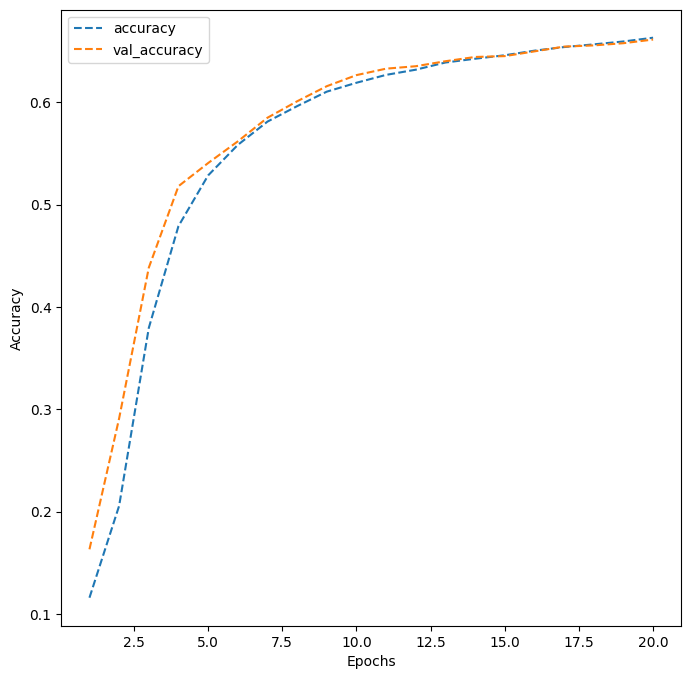

In [13]:
#Cell Kappa - Plot the Training and Validation Accuracies

dict_hist = history_model_1.history
list_ep = list(range(1, len(dict_hist["accuracy"]) + 1))

plt.figure(figsize = (8, 8))

plt.plot(list_ep, dict_hist['accuracy'], ls = '--', label = 'accuracy')

plt.plot(list_ep, dict_hist['val_accuracy'], ls = '--', label = 'val_accuracy')

plt.ylabel('Accuracy')

plt.xlabel('Epochs')

plt.legend()

plt.show()

**Observations:**
Training and validation accuracy rose together and stayed close; by epoch 20 gains had slowed, suggesting the model was near what this ANN setup can reach without architecture changes.

Let's build one more model with higher complexity and see if we can improve the performance of the model.

First, we need to clear the previous model's history from the Keras backend. Also, let's fix the seed again after clearing the backend.

In [14]:
#Cell Lambda - Clear the previous model's history from the Keras backend, then set the seed again
from tensorflow.keras import backend

backend.clear_session()

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)


### **Second Model Architecture**
- Write a function that returns a sequential model with the following architecture:
 - First hidden layer with **256 nodes and the relu activation** and the **input shape = (1024, )**
 - Second hidden layer with **128 nodes and the relu activation**
 - Add the **Dropout layer with the rate equal to 0.2**
 - Third hidden layer with **64 nodes and the relu activation**
 - Fourth hidden layer with **64 nodes and the relu activation**
 - Fifth hidden layer with **32 nodes and the relu activation**
 - Add the **BatchNormalization layer**
 - Output layer with **activation as 'softmax' and number of nodes equal to the number of classes, i.e., 10**
 -Compile the model with the **loss equal to categorical_crossentropy, optimizer equal to Adam(learning_rate = 0.0005), and metric equal to 'accuracy'**. Do not fit the model here, just return the compiled model.
- Call the nn_model_2 function and store the model in a new variable.
- Print the summary of the model.
- Fit on the train data with a **validation split of 0.2, batch size = 128, verbose = 1, and epochs = 30**. Store the model building history to use later for visualization.

### **Build and train the new ANN model as per the above mentioned architecture**

In [15]:
#Cell 12 - ANN Model Architecture v2
def nn_model_2():
    model = Sequential()
    # First hidden layer
    model.add(Dense(256, activation="relu", input_shape=(1024,)))
    # Second hidden layer
    model.add(Dense(128, activation="relu"))
    # Dropout layer
    model.add(Dropout(0.2))
    # Third hidden layer
    model.add(Dense(64, activation="relu"))
    # Fourth hidden layer
    model.add(Dense(64, activation="relu"))
    # Fifth hidden layer
    model.add(Dense(32, activation="relu"))
    # BatchNormalization layer
    model.add(BatchNormalization())
    # Output layer
    model.add(Dense(10, activation="softmax"))
    model.compile(
        loss="categorical_crossentropy",
        optimizer=Adam(learning_rate=0.0005),
        metrics=["accuracy"],
    )
    return model

model_2 = nn_model_2()
model_2.summary()
X_train_flat = X_train.reshape(X_train.shape[0], 1024)   # or reshape(-1, 1024)
history_model_2 = model_2.fit(
    X_train_flat,
    y_train,
    validation_split=0.2,
    batch_size=128,
    verbose=1,
    epochs=30,
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 310,250 (1.18 MB)

 Trainable params: 310,186 (1.18 MB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1024 - loss: 2.3819 - val_accuracy: 0.1106 - val_loss: 2.3066
Epoch 2/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1246 - loss: 2.2914 - val_accuracy: 0.1475 - val_loss: 2.2709
Epoch 3/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3024 - loss: 1.9453 - val_accuracy: 0.4079 - val_loss: 1.7478
Epoch 4/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4834 - loss: 1.5316 - val_accuracy: 0.5685 - val_loss: 1.3619
Epoch 5/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5853 - loss: 1.2849 - val_accuracy: 0.6048 - val_loss: 1.2179
Epoch 6/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6281 - loss: 1.1650 - val_accuracy: 0.6768 - val_loss: 1.0462
Epoch 7/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6490 - loss: 1.0972 - val_accuracy: 0.6694 - val_loss: 1.0255
Epoch 8/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6666 - loss: 1.0501 - val_accuracy: 0.

### **Plot the Training and Validation Accuracies and write down your Observations.**

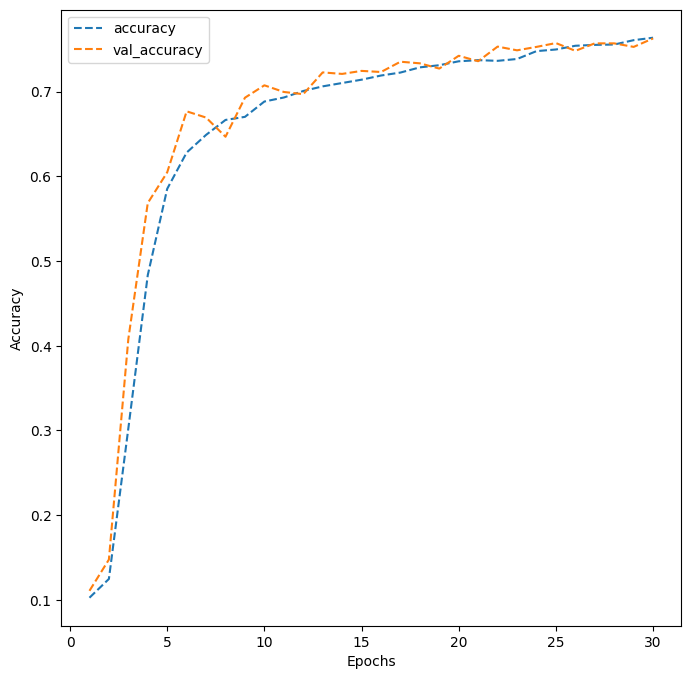

In [16]:
#Cell Mu - Plot the Training and Validation Accuracies for Model ANN v2

dict_hist = history_model_2.history
list_ep = list(range(1, len(dict_hist["accuracy"]) + 1))

plt.figure(figsize = (8, 8))

plt.plot(list_ep, dict_hist['accuracy'], ls = '--', label = 'accuracy')

plt.plot(list_ep, dict_hist['val_accuracy'], ls = '--', label = 'val_accuracy')

plt.ylabel('Accuracy')

plt.xlabel('Epochs')

plt.legend()

plt.show()

**Observations:**
Model 2 is learning more (higher accuracy), and the validation curve looks rougher mainly because it’s a noisier, one-shot metric per epoch, while training is smoother because it’s averaged over batches — with a bit of extra wiggle possible from regularization and a richer network.

## **Predictions on the test data**

- Make predictions on the test set using the second model.
- Print the obtained results using the classification report and the confusion matrix.
- Final observations on the obtained results.

In [21]:
#Cell Nu - Make predictions on the test set using the second model
X_test_flat = X_test.reshape(X_test.shape[0], 1024)
test_pred = model_2.predict(X_test_flat, batch_size=128)  # batch optional
test_pred = np.argmax(test_pred, axis=-1)

# Converting each entry to single label from one-hot encoded vector
y_test = np.argmax(y_test, axis = -1)

141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 780us/step


**Note:** Earlier, we noticed that each entry of the target variable is a one-hot encoded vector but to print the classification report and confusion matrix, we must convert each entry of y_test to a single label.

### **Print the classification report and the confusion matrix for the test predictions. Write your observations on the final results.**

              precision    recall  f1-score   support

           0       0.74      0.82      0.78      1814
           1       0.71      0.84      0.77      1828
           2       0.87      0.73      0.80      1803
           3       0.69      0.72      0.71      1719
           4       0.78      0.84      0.81      1812
           5       0.72      0.74      0.73      1768
           6       0.77      0.75      0.76      1832
           7       0.77      0.80      0.78      1808
           8       0.78      0.68      0.72      1812
           9       0.82      0.68      0.74      1804

    accuracy                           0.76     18000
   macro avg       0.76      0.76      0.76     18000
weighted avg       0.76      0.76      0.76     18000

[[1495   56   10   40   44   13   54   29   31   42]
 [  39 1541   10   38   60   22   24   60   17   17]
 [  36   43 1323   79   50   31   17  162   27   35]
 [  32   84   28 1241   29  167   15   55   47   21]
 [  51   61   16   20 1522   

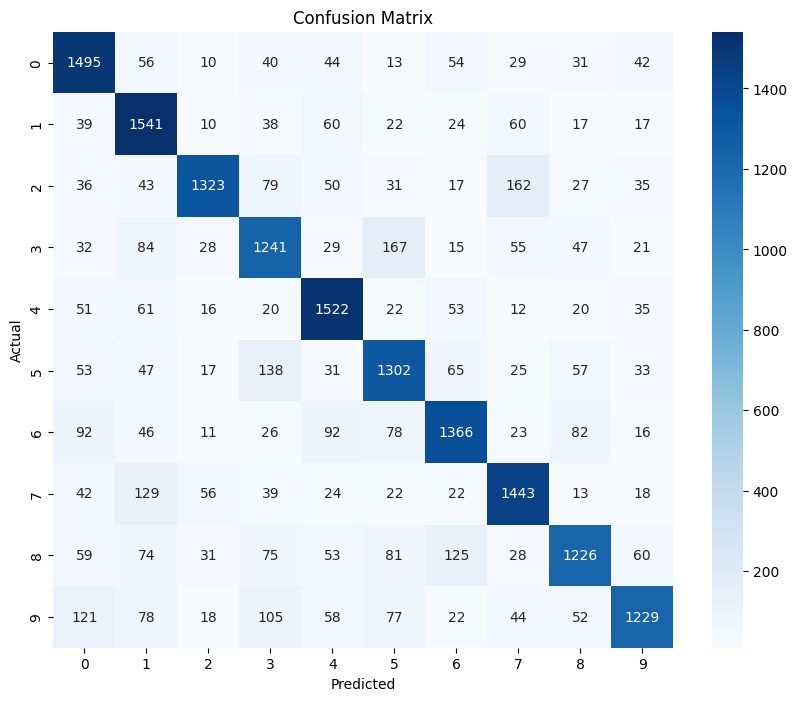

In [24]:
# Cell Xi - Print the classification report and the confusion matrix for the test predictions
class_report = classification_report(y_test, test_pred)
print(class_report)

conf_matrix = confusion_matrix(y_test, test_pred)
print(conf_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


**Final Observations:**

**Overall**
Test accuracy ~76% on 18,000 samples, with macro and weighted averages both ~0.76, so performance is fairly balanced across digits (no single class is carrying or tanking the average).

**Per-class behavior**
- Stronger digits (F1 ~0.78–0.81): 0, 1, 4, 7 generally good precision and recall.
- Digit 2: High precision (0.87) but lower recall (0.73) the model is cautious when it says “2” but misses some true 2s.
- Weaker F1 (~0.71–0.74): 3, 5, 8, 9 especially lower recall on 8 and 9 (~0.68), so those classes are harder to find (more false negatives).

**Confusion matrix (what the errors look like)**
The off-diagonal mass tells the story:
- 2 & 7: Many true 2s predicted as 7 (and some the other way), visually similar in cropped digits.
- 3 & 5: Strong confusion (e.g. many 3↔5 swaps), a classic SVHN / street-number ambiguity.
- 6 & 0 / 4: Some confusion with 0 and 4, shared curves and clutter.
- 8 & 5 / 6: 8s confused with 5 and 6, loops and stroke patterns overlap.

That pattern is typical for a flattened ANN on SVHN: no translation-invariant features, so confusions cluster on visually similar digit pairs.

**Takeaway**
~76% is a reasonable ANN baseline on this task; CNNs usually do better because they learn local patterns.

## **Using Convolutional Neural Networks**

### **Load the dataset again and split the data into the train and the test dataset.**

In [27]:
# Cell Alpha_2 - Load the dataset again and split the data into the train and the test dataset.
# Open the .h5 here so this section works after a kernel restart (h5f / data_svhn from earlier cells may not exist).
import h5py
h5f = h5py.File(filepath, 'r')

X_train = h5f['X_train'][:]
y_train = h5f['y_train'][:]
X_test  = h5f['X_test'][:]
y_test  = h5f['y_test'][:]

h5f.close()

Check the number of images in the training and the testing dataset.

In [30]:
# Cell Beta_2 - Check the number of images in the training and the testing dataset
print(f"Number of images in the TRAIN dataset: {X_train.shape[0]}")
print(f"Number of images in the TEST dataset: {X_test.shape[0]}")

Number of images in the TRAIN dataset: 42000
Number of images in the TEST dataset: 18000


**Observation:**


## **Data preparation**

- Print the shape and the array of pixels for the first image in the training dataset.
- Reshape the train and the test dataset because we always have to give a 4D array as input to CNNs.
- Normalize the train and the test dataset by dividing by 255.
- Print the new shapes of the train and the test dataset.
- One-hot encode the target variable.

Reshape the dataset to be able to pass them to CNNs. Remember that we always have to give a 4D array as input to CNNs

Normalize inputs from 0-255 to 0-1

Print New shape of Training and Test

### **One-hot encode the labels in the target variable y_train and y_test.**

**Observation:**


## **Model Building**

Now that we have done data preprocessing, let's build a CNN model.
Fix the seed for random number generators

### **Model Architecture**
- **Write a function** that returns a sequential model with the following architecture:
 - First Convolutional layer with **16 filters and the kernel size of 3x3**. Use the **'same' padding** and provide the **input shape = (32, 32, 1)**
 - Add a **LeakyRelu layer** with the **slope equal to 0.1**
 - Second Convolutional layer with **32 filters and the kernel size of 3x3 with 'same' padding**
 - Another **LeakyRelu** with the **slope equal to 0.1**
 - A **max-pooling layer** with a **pool size of 2x2**
 - **Flatten** the output from the previous layer
 - Add a **dense layer with 32 nodes**
 - Add a **LeakyRelu layer with the slope equal to 0.1**
 - Add the final **output layer with nodes equal to the number of classes, i.e., 10** and **'softmax' as the activation function**
 - Compile the model with the **loss equal to categorical_crossentropy, optimizer equal to Adam(learning_rate = 0.001), and metric equal to 'accuracy'**. Do not fit the model here, just return the compiled model.
- Call the function cnn_model_1 and store the output in a new variable.
- Print the summary of the model.
- Fit the model on the training data with a **validation split of 0.2, batch size = 32, verbose = 1, and epochs = 20**. Store the model building history to use later for visualization.

### **Build and train a CNN model as per the above mentioned architecture.**

### **Plot the Training and Validation Accuracies and Write your observations.**

**Observations:__________**

Let's build another model and see if we can get a better model with generalized performance.

First, we need to clear the previous model's history from the Keras backend. Also, let's fix the seed again after clearing the backend.

### **Second Model Architecture**

- Write a function that returns a sequential model with the following architecture:
 - First Convolutional layer with **16 filters and the kernel size of 3x3**. Use the **'same' padding** and provide the **input shape = (32, 32, 1)**
 - Add a **LeakyRelu layer** with the **slope equal to 0.1**
 - Second Convolutional layer with **32 filters and the kernel size of 3x3 with 'same' padding**
 - Add **LeakyRelu** with the **slope equal to 0.1**
 - Add a **max-pooling layer** with a **pool size of 2x2**
 - Add a **BatchNormalization layer**
 - Third Convolutional layer with **32 filters and the kernel size of 3x3 with 'same' padding**
 - Add a **LeakyRelu layer with the slope equal to 0.1**
 - Fourth Convolutional layer **64 filters and the kernel size of 3x3 with 'same' padding**
 - Add a **LeakyRelu layer with the slope equal to 0.1**
 - Add a **max-pooling layer** with a **pool size of 2x2**
 - Add a **BatchNormalization layer**
 - **Flatten** the output from the previous layer
 - Add a **dense layer with 32 nodes**
 - Add a **LeakyRelu layer with the slope equal to 0.1**
 - Add a **dropout layer with the rate equal to 0.5**
 - Add the final **output layer with nodes equal to the number of classes, i.e., 10** and **'softmax' as the activation function**
 - Compile the model with the **categorical_crossentropy loss, adam optimizers (learning_rate = 0.001), and metric equal to 'accuracy'**. Do not fit the model here, just return the compiled model.
- Call the function cnn_model_2 and store the model in a new variable.
- Print the summary of the model.
- Fit the model on the train data with a **validation split of 0.2, batch size = 128, verbose = 1, and epochs = 30**. Store the model building history to use later for visualization.

### **Build and train the second CNN model as per the above mentioned architecture.**

### **Plot the Training and Validation accuracies and write your observations.**

**Observations:________**

## **Predictions on the test data**

- Make predictions on the test set using the second model.
- Print the obtained results using the classification report and the confusion matrix.
- Final observations on the obtained results.

### **Make predictions on the test data using the second model.**

**Note:** Earlier, we noticed that each entry of the target variable is a one-hot encoded vector, but to print the classification report and confusion matrix, we must convert each entry of y_test to a single label.

### **Write your final observations on the performance of the model on the test data.**

**Final Observations:_________**